# Stage 08: Exploratory Data Analysis

This notebook summarizes and visualizes the Stage 06 S&P 500 data to identify data-quality concerns and feature hypotheses for later modeling.

## Scope and Assumptions

- The first daily return, which Stage 06 set to zero because there was no earlier close, is excluded from return analysis.
- The remaining 18 observations cover January 2025 only. Descriptive patterns are not assumed to generalize to other market regimes.
- EDA informs later feature-engineering choices; it does not establish causal or predictive relationships.

In [1]:
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import sys

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(context='talk', style='whitegrid')
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework08').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework08'
load_dotenv(HOMEWORK_DIR / '.env')
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_PROCESSED', 'data/processed')
REPORTS_DIR = HOMEWORK_DIR / os.environ.get('REPORTS_DIR', 'reports')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / 'src'))
from eda_utils import correlation_matrix, eda_summary, strongest_pairwise_correlation

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')

Matplotlib is building the font cache; this may take a moment.


## Load and Profile the Data
The Stage 06 Parquet file is already type-corrected and validated. Return analysis starts after the artificial first zero return.

In [2]:
stage06_processed_dir = REPO_ROOT / 'homework' / 'homework06' / 'data' / 'processed'
source_files = sorted(stage06_processed_dir.glob('sp500_prices_cleaned_*.parquet'))
if not source_files:
    raise FileNotFoundError('Run the Stage 06 notebook first so cleaned data are available.')

source_path = source_files[-1]
prices = pd.read_parquet(source_path).sort_values('date').reset_index(drop=True)
eda_data = prices.iloc[1:].copy().reset_index(drop=True)
analysis_columns = ['close', 'volume', 'daily_return', 'close_minmax', 'volume_zscore']
summary = eda_summary(eda_data, analysis_columns)
print('Shape:', summary['shape'])
display(summary['numeric_profile'])
print('Missing values:', summary['missing'])

Shape: (18, 10)


/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,18.0,5981.829444,95.538216,5827.04,5916.1075,5986.02,6063.085,6118.71,-0.249228,-1.230167
volume,18.0,4442785277.777778,296731967.559913,3667340000.0,4333987500.0,4439367500.0,4612107500.0,4940120000.0,-0.693743,0.907925
daily_return,18.0,0.001636,0.007941,-0.011104,-0.004665,0.001361,0.005988,0.018313,0.299171,-0.663612
close_minmax,18.0,0.530701,0.327556,0.0,0.305371,0.545068,0.809288,1.0,-0.249228,-1.230167
volume_zscore,18.0,0.128903,0.885082,-2.184069,-0.195615,0.118709,0.633952,1.612337,-0.693743,0.907925


Missing values: {'date': 0, 'ticker': 0, 'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0, 'daily_return': 0, 'close_minmax': 0, 'volume_zscore': 0}


## Univariate Distributions
Histograms and boxplots show location, spread, skew, and potential extreme observations in the return and volume series.

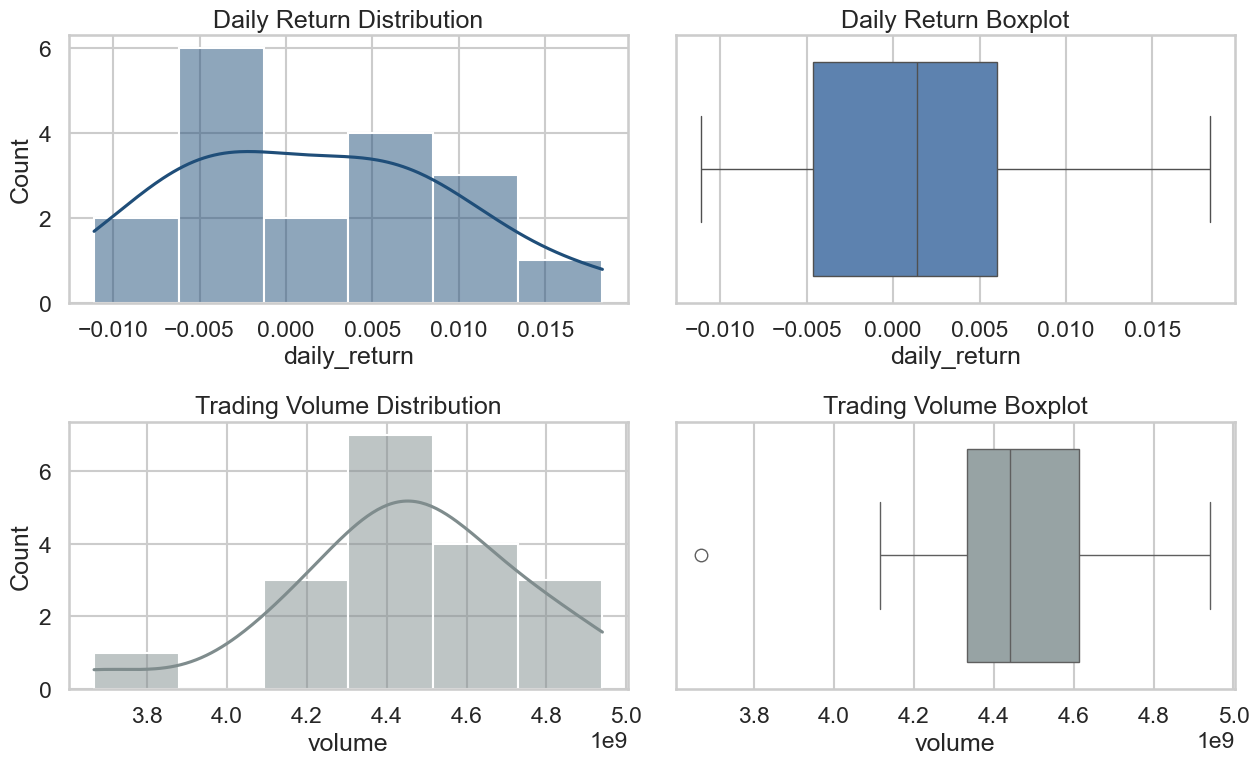

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(eda_data['daily_return'], kde=True, ax=axes[0, 0], color='#1f4e79')
axes[0, 0].set_title('Daily Return Distribution')
sns.boxplot(x=eda_data['daily_return'], ax=axes[0, 1], color='#4f81bd')
axes[0, 1].set_title('Daily Return Boxplot')
sns.histplot(eda_data['volume'], kde=True, ax=axes[1, 0], color='#7f8c8d')
axes[1, 0].set_title('Trading Volume Distribution')
sns.boxplot(x=eda_data['volume'], ax=axes[1, 1], color='#95a5a6')
axes[1, 1].set_title('Trading Volume Boxplot')
plt.tight_layout()
distribution_plot_path = REPORTS_DIR / f'eda_distributions_{RUN_TIMESTAMP}.png'
plt.savefig(distribution_plot_path, dpi=150)
plt.show()

## Relationships and Correlations
The scatterplots examine whether unusually high standardized volume coincides with larger absolute returns and how closing level relates to the realized daily move.

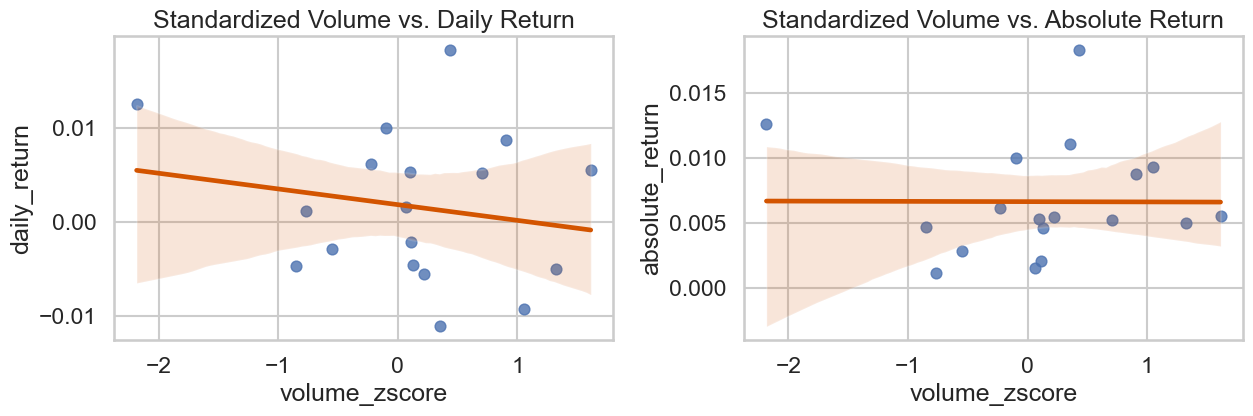

,close,volume,daily_return
close,1.000000,0.032575,0.193888
volume,0.032575,1.000000,-0.186650
daily_return,0.193888,-0.186650,1.000000


In [4]:
eda_data['absolute_return'] = eda_data['daily_return'].abs()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(data=eda_data, x='volume_zscore', y='daily_return', ax=axes[0], scatter_kws={'s': 60}, line_kws={'color': '#d35400'})
axes[0].set_title('Standardized Volume vs. Daily Return')
sns.regplot(data=eda_data, x='volume_zscore', y='absolute_return', ax=axes[1], scatter_kws={'s': 60}, line_kws={'color': '#d35400'})
axes[1].set_title('Standardized Volume vs. Absolute Return')
plt.tight_layout()
relationship_plot_path = REPORTS_DIR / f'eda_relationships_{RUN_TIMESTAMP}.png'
plt.savefig(relationship_plot_path, dpi=150)
plt.show()

correlation_columns = ['close', 'volume', 'daily_return']
correlation = correlation_matrix(eda_data, correlation_columns)
display(correlation)

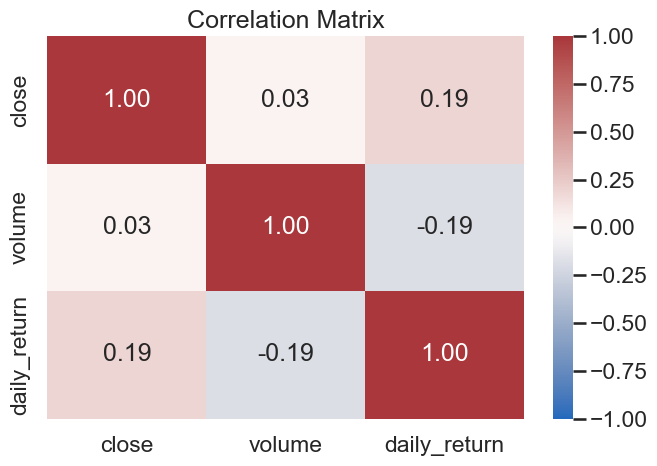

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
correlation_plot_path = REPORTS_DIR / f'eda_correlation_matrix_{RUN_TIMESTAMP}.png'
plt.savefig(correlation_plot_path, dpi=150)
plt.show()

## Time-Series Glance
Closing levels are shown with a three-trading-day rolling average. Volume is shown separately so its scale does not obscure price movement.

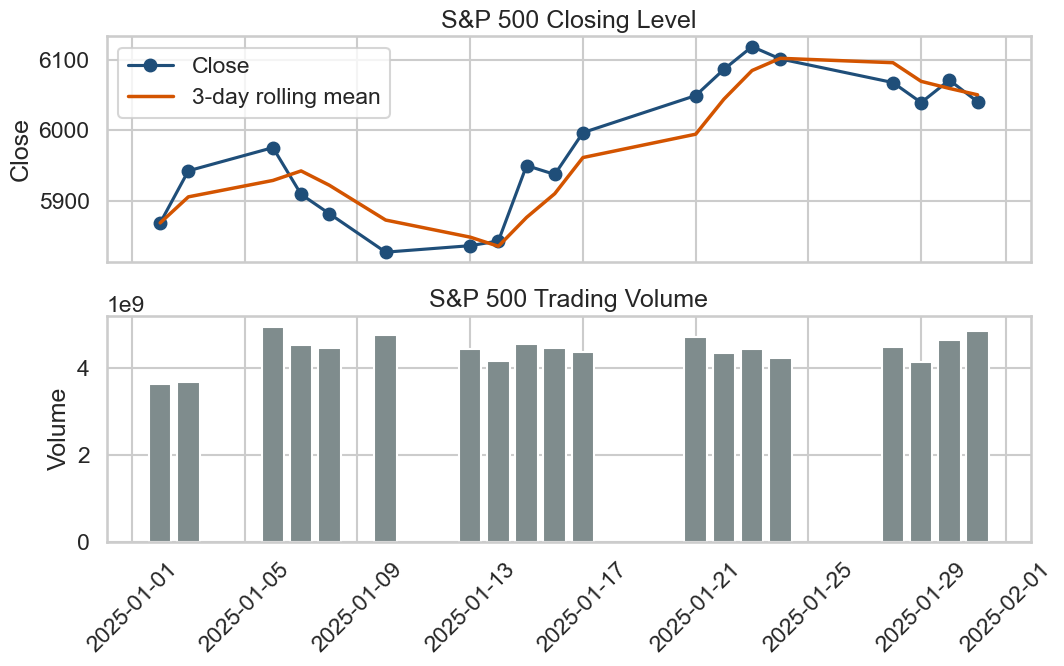

In [6]:
prices_for_time = prices.copy()
prices_for_time['close_3day_mean'] = prices_for_time['close'].rolling(window=3, min_periods=1).mean()
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(prices_for_time['date'], prices_for_time['close'], marker='o', label='Close', color='#1f4e79')
axes[0].plot(prices_for_time['date'], prices_for_time['close_3day_mean'], linewidth=2.5, label='3-day rolling mean', color='#d35400')
axes[0].set_title('S&P 500 Closing Level')
axes[0].set_ylabel('Close')
axes[0].legend()
axes[1].bar(prices_for_time['date'], prices_for_time['volume'], color='#7f8c8d', width=0.8)
axes[1].set_title('S&P 500 Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
time_series_plot_path = REPORTS_DIR / f'eda_time_series_{RUN_TIMESTAMP}.png'
plt.savefig(time_series_plot_path, dpi=150)
plt.show()

## Save Summary and Modeling Implications
The automated report connects descriptive facts to cautious next steps for feature engineering.

In [7]:
profile_path = PROCESSED_DIR / f'numeric_profile_{RUN_TIMESTAMP}.csv'
correlation_path = PROCESSED_DIR / f'correlation_matrix_{RUN_TIMESTAMP}.csv'
summary_path = PROCESSED_DIR / f'eda_summary_{RUN_TIMESTAMP}.json'
summary['numeric_profile'].to_csv(profile_path)
correlation.to_csv(correlation_path)

strongest_left, strongest_right, strongest_value = strongest_pairwise_correlation(correlation)
largest_move = eda_data.loc[eda_data['absolute_return'].idxmax()]
summary_json = {
    'source_file': str(source_path.relative_to(REPO_ROOT)),
    'observations': int(len(eda_data)),
    'missing_values': {key: int(value) for key, value in summary['missing'].items()},
    'largest_absolute_return': {
        'date': str(largest_move['date'].date()),
        'daily_return': float(largest_move['daily_return']),
    },
    'strongest_pairwise_correlation': {
        'variables': [strongest_left, strongest_right],
        'value': strongest_value,
    },
    'outputs': {
        'profile': str(profile_path.relative_to(REPO_ROOT)),
        'correlation': str(correlation_path.relative_to(REPO_ROOT)),
        'distribution_plot': str(distribution_plot_path.relative_to(REPO_ROOT)),
        'relationship_plot': str(relationship_plot_path.relative_to(REPO_ROOT)),
        'correlation_plot': str(correlation_plot_path.relative_to(REPO_ROOT)),
        'time_series_plot': str(time_series_plot_path.relative_to(REPO_ROOT)),
    },
}
summary_path.write_text(json.dumps(summary_json, indent=2), encoding='utf-8')

insights = f'''# Stage 08 EDA Insights

- The analysis contains {len(eda_data)} usable daily returns and no missing values after Stage 06 preprocessing.
- The largest absolute return was {largest_move['daily_return']:.2%} on {largest_move['date'].date()}. This observation remains below the Stage 07 IQR and Z-score thresholds, but it should remain visible in later model diagnostics.
- The strongest non-duplicate correlation is between `{strongest_left}` and `{strongest_right}` ({strongest_value:.2f}). Correlation in this short sample is descriptive, not causal.
- Next feature hypotheses: lagged returns, rolling volatility, and volume-relative features. Each must be calculated without using future observations.
- Limitation: January 2025 alone cannot represent calm, stressed, or changing market regimes. A longer data history is required before model evaluation.
'''
insights_path = REPORTS_DIR / 'eda_insights.md'
insights_path.write_text(insights, encoding='utf-8')

assert pd.read_csv(profile_path, index_col=0).shape[0] == len(analysis_columns)
assert pd.read_csv(correlation_path, index_col=0).shape == (3, 3)
print('Saved EDA outputs:', profile_path.name, correlation_path.name, summary_path.name, insights_path.name)

Saved EDA outputs: numeric_profile_20260820-051246.csv correlation_matrix_20260820-051246.csv eda_summary_20260820-051246.json eda_insights.md
